<a href="https://colab.research.google.com/github/kduran-stack/climate_collection_kd/blob/main/heatwave_mapping_tut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kyla Duran: Mapping and Monitoring Heatwaves Using Xee



To expand my climate analysis skillset, I will be learning how to use **Google Earth Engine** inspired by a tutorial by Amirhossein Ahrari.

Due to updated technology, I had to deviate from the tutorial at many points, especially when loading in the grid. This forced me to understand every piece of the code and the modifications that were needed for the code to run.

All code will either be written from learing through the tutorial or by reading guides online (AI will only be used in debugging cases).

# Skills
**The following notebook I will be loading in, cleaning, and working with: 3500+ datapoints**

**All comments and analysis were researched by Kyla Duran and are additions to the tutorial found at the link below**

Tutorial Link: https://www.youtube.com/watch?v=ZzpSV9ca7v4&t=246s

In [91]:
#installs
"""
What is Xee?
Xee is a Python library which allows you to use Google Engine Data without downloading massive amounts of data. The name Xee is a combination of Xarray and Earth Engine.
"""
!pip install --upgrade xee
!pip install -U geemap

In [92]:
import ee
import xarray as xr

In [93]:
from google.colab import userdata
project_id=userdata.get('project_id')

ee.Authenticate()

ee.Initialize(
    project=project_id,
    opt_url="https://earthengine-highvolume.googleapis.com" #from Xee's Github
)

In [94]:
import geemap

In [97]:
map = geemap.Map()
map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [98]:
#draw_last_feature: tracks last shape drawn out on the geemap
#geometry: extracts spatial coordinates of the boundary lines from that drawing, converting it into a formal Google Earth Engine object
#Variable name= region of interest= roi

roi = map.draw_last_feature.geometry()
roi

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "Feature.geometry",
    "arguments": {
      "feature": {
        "functionInvocationValue": {
          "functionName": "Feature",
          "arguments": {
            "geometry": {
              "functionInvocationValue": {
                "functionName": "GeometryConstructors.Polygon",
                "arguments": {
                  "coordinates": {
                    "constantValue": [
                      [
                        [
                          -372.128906,
                          37.439974
                        ],
                        [
                          -372.128906,
                          51.944265
                        ],
                        [
                          -323.085938,
                          51.944265
                        ],
                        [
                          -323.085938,
                          37.439974
                        ],
                        [
                          -372.128906,
                          37.439974
                        ]
                      ]
                    ]
                  },
                  "geodesic": {
                    "constantValue": false
                  }
                }
              }
            }
          }
        }
      }
    }
  }
})

In [99]:
#xclim official documentation:  https://xclim.readthedocs.io/en/stable/
#xclim Climate Indicators: https://xclim.readthedocs.io/en/stable/indicators.html

!pip install xclim
import xclim

In [100]:
#Using the ERA5 daily atmospheric dataset
#Dates: January 1, 2010, through December 31, 2019
#Climate Indicator: Highest temperature recorded 2m above the ground each day

# era5 = (
#     ee.ImageCollection("ECMWF/ERA5/DAILY")
#     .filterDate('2010','2020')
#     .select(['maximum_2m_air_temperature'],['tmax']) #renaming variable tmax
# )

# era5 = (
#     ee.ImageCollection("ECMWF/ERA5/DAILY")
#     .filterDate("2010-01-01", "2020-01-01")
#     .select("maximum_2m_air_temperature")
#     .map(
#         lambda img: img.subtract(273.15) #273.15K = 0 celsius (masking 0's from the data)
#         .rename("tmax")
#         .copyProperties(img, ["system:time_start"])
#     )
# )

# era5

# Finding a new solution: for updated Xee since the tutorial was posted (Anaylsis by Kyla Duran)

Some of the fields for the xr.open_dataset model specified in the tutorial, will not work with the Xee update. Inorder to fix it, I read Xee documentation, and asked Chatgpt, to help fix the problem.


The previous solution will not work:

ds = xr.open_dataset(
    data,
    engine = 'ee', activates xee which tells xarray to look for the data in the Google Earth Engine
    crs = 'EPSG:4326', Coordinate Reference System (ensuring lat/long projection aligns with global maps) (you can always use this)
    scale = 0.3, spatial resolution (.3 degree square box) (30 km)
    geometry = roi (region of interest)
)

Updated Changes:

1. Using the previous, Xee version, it allowed us to use geometry =roi (area of interest), to figure out the raster grid. This updated version, wants an explicit definiton of what the grid will be. This is done using:

roi_shapely = shape(roi.getInfo) and then plugging that into the grid.

2. Defining scale:

The tutorial defines the scale of the grid with scale=0.3. With the update x,y must be defined.

I used 0.25,-0.25. x=0.25, starting at the westernmost coordinate of the grid (-4.83 W) and moving East by a +0.25 step per pixel. y= -0.25, starting at the top of grid moving Southward by a -0.25 step doward. (Explicitly stating negative and positive here is very important, because it defines the direction python will start reading your grid).


# Summary of New Xee style:

**Old Xee: **

type: EE ImageCollection (from ee geemap of ROI) --> define ROI and scale --> xarray provides Ds

** Xee 0.1.2: **

type: EE ImageCollection (from ee geemap of ROI) --> explicit raster grid defined(CRS,transform, dimensions) --> xarray provides Ds

**Middle step is the only thing that changes**



In [110]:
from shapely.geometry import shape
from xee import helpers
from xclim.indicators.atmos import heat_wave_index


roi_shapely = shape(roi.getInfo()) #boundary box

grid = helpers.fit_geometry(
    geometry=roi_shapely,
    geometry_crs="EPSG:4326", #tells computer that the geometry are lat/lot, not another unit of measure such as meters
    grid_crs="EPSG:4326", #telling xarray to save the final ds as lat and lon
    grid_scale=(0.25, -0.25)  # Native ERA5 resolution grid step size
)

# Requesting data based off filtered grid within a specific window
era5 = (
    ee.ImageCollection("ECMWF/ERA5/DAILY")
    .filterDate("2010", "2020")
    .select("maximum_2m_air_temperature")
)

ds = xr.open_dataset(era5, engine="ee", **grid)

#extracting variable of interest from xclim official documentation

tmax_raw = ds["maximum_2m_air_temperature"]

# "saving" data to local memory (computer)
tmax_local_kelvin = tmax_raw.compute()

# now that data is stored we can do unit conversions
tmax_celsius = tmax_local_kelvin - 273.15
tmax_celsius.attrs["units"] = "degC"

# print("(C) Clean Temperature values:", tmax_celsius.values) (checking the values before plotting)

hw2  = heat_wave_index(
    tasmax = tmax_celsius,
    thresh = '25 degC',
    window = 5,
    freq = 'YS'
)

# pic = plt.subplots(figsize=(12, 8))

import matplotlib.pyplot as plt
pic =hw2.plot.contourf(
    x='x',
    y='y',
    col='time',
    col_wrap=5,
    cmap='turbo', #color-palette
    levels=15,
)
pic.fig.savefig("new_hw2_westerneu.png", dpi=360, bbox_inches="tight")
plt.close(pic.fig)



Note: Change temperature threshold for defining a heatwave from 25 C to standard definition. This will account for different locations around the world.

To deal with this: we will convert the temperature values.

sortby(time) ensure the data is in chrnological order, -273.15 converts Kelvin to Celcius.

Recall: C = K -273.15

In [104]:
#checking how many points are the dataset:

print(ds.dims)

#3652 - daily time step values
#60 x direction grid cells
#289 y direction grid cells

FrozenMappingWarningOnValuesAccess({'time': 3652, 'y': 59, 'x': 197})


xclim helps us define what "heatwave" actually means. The World Meteorological Organization (WMO): "states that a heatwave occurs when daily maximum temperatures exceed the normal maximum by at least 5 degrees celcius (9F) for more than five consecutive days (based on the 1961-1990 baseline)."

**Mathematically this looks like: Tmax(t) > Tnormal(t) + 5C**

The heatwave indicator needs these pieces of data:

Tmax, Tnorm, 5C or whatever the specific definition of heatwave is.

**Code I will be using for my specific region (not related to tutorial): **

tasmax = daily max
thresh = it is hot if it is above 25 degrees celcius (I will tweak this for western Europe)

Averaging the thresholds for western europen regions in my roi during the daytime:

-France: 31 C

- Spain and Portugal: 33 C

-Germay 32 C

In Western European regions heat wave events are declared after 3 consecutive days rather than the five suggested by the WMO.

Window = 1-3


In [105]:
#heatwave =hw
avg = ((31+32+33)/3)

print(f"Thresh for ROI will be: {avg}")


Thresh for ROI will be: 32.0


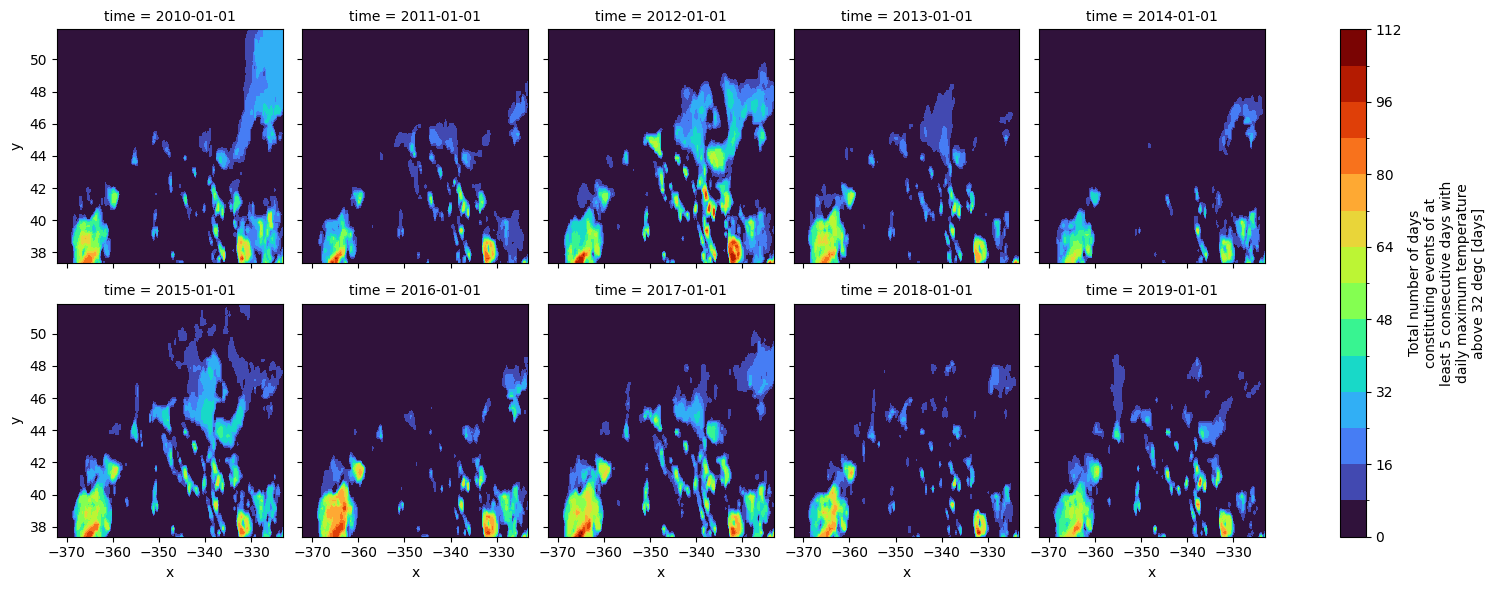

In [112]:

hw  = heat_wave_index(
    tasmax = tmax_celsius,
    thresh = '32 degC',
    window = 5,
    freq = 'YS'
)

# pic = plt.subplots(figsize=(12, 8))

import matplotlib.pyplot as plt
hw.plot.contourf(
    x='x',
    y='y',
    col='time',
    col_wrap=5,
    cmap='turbo', #color-palette
    levels=15,
)
pic.fig.savefig("new_hw_westerneu.png", dpi=360, bbox_inches="tight")
plt.close(pic.fig)

This is has produced a much more conservative assessment of heatwave events in Western Europe from 2010-2019. Reducing the highest number of events per year by almost 100 days from 210 days (Graph 1) to 96 (Graph 2).